This script aims to investigate if there is a difference in a prediction of a long and a short input sequence. Predictions with the tools was made on three input sequences. All thre sequences are Caplaziumab, but frist inputed as a singular, then the sequence was copied and made into a twice sequence (same sequence repeated twice) and one with 3 copies. 

In [7]:
# load libaries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

In [8]:
# load data
netMHC1_defaultSettings = pd.read_csv('tool_outputs/netMHC1_EL_defaultSettings.csv')
netMHC_II_defaultSettings = pd.read_csv('tool_outputs/netMHC_II_EL_defaultSettings.csv')
seqTable = pd.read_csv('tool_outputs/seqTable_netMHC1_EL_defaultSettings.csv')

In [9]:
# map the sequence names
netMHC1_defaultSettings = netMHC1_defaultSettings.merge(seqTable[['seq #', 'sequence name']], how='left')
netMHC_II_defaultSettings = netMHC_II_defaultSettings.merge(seqTable[['seq #', 'sequence name']], how='left')

In [10]:
# netMHC1_EL_pep9 percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_pep9_percentile = (
    netMHC1_defaultSettings.assign(immunogenic=netMHC1_defaultSettings['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_pep9_percentile')
    )

# netMHC1_EL_pep9 Immunogenicity score 

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
class1pMHC_immunogen_pep9 = (
    netMHC1_defaultSettings.assign(immunogenic=netMHC1_defaultSettings['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='class1pMHC_immunogen_pep9')
    )

# netMHC1_EL_pep9 Preprocessing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
basicPreProcessMHC1_pep9 = netMHC1_defaultSettings.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMHC1_pep9_preProcess'})



# netMHC_II_EL_pep15

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_pep15_percentile = (
    netMHC_II_defaultSettings.assign(immunogenic=netMHC_II_defaultSettings['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_pep15_percentile')
    )

# Immunogenicity score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
CD4Episcore_pep15 = netMHC_II_defaultSettings.groupby('sequence name')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'CD4Episcore_pep15'})

# Pre-proocessing score
# MHC class 2 has 2 preprocessing scores of interest: mhcii-np cleavage probability score and mhcii-np cleavage probability percentile rank

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_defaultSettings[netMHC_II_defaultSettings['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_pep15_cleavProb = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'mhcii-np cleavage probability score': 'MHCII_NP_pep15_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_EL_pep15 = netMHC_II_EL_pep15[netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_pep15_cleavProbPercentile = netMHC_II_EL_pep15.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'MHCII_NP_pep15_cleavProbPercentile'})



C:\Users\rebbe\AppData\Local\Temp\ipykernel_11696\1881044221.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netMHC_II_EL_pep15['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_EL_pep15['mhcii-np cleavage probability score'])


In [11]:
# Merge scores
all_predictors = netMHC1_pep9_percentile.merge(class1pMHC_immunogen_pep9, on='sequence name', how='left')
all_predictors = all_predictors.merge(basicPreProcessMHC1_pep9, on='sequence name', how='left')
all_predictors = all_predictors.merge(netMHC_II_pep15_percentile, on='sequence name', how='left')
all_predictors = all_predictors.merge(CD4Episcore_pep15, on='sequence name', how='left')
all_predictors = all_predictors.merge(MHCII_NP_pep15_cleavProb, on='sequence name', how='left')
all_predictors = all_predictors.merge(MHCII_NP_pep15_cleavProbPercentile, on='sequence name', how='left')

In [12]:
all_predictors

,sequence name,netMHC1_pep9_percentile,class1pMHC_immunogen_pep9,netMHC1_pep9_preProcess,netMHC_II_pep15_percentile,CD4Episcore_pep15,MHCII_NP_pep15_cleavProb,MHCII_NP_pep15_cleavProbPercentile
0,Caplacizumab,3.549383,53.333333,-3.381630,10.466989,94.663083,0.121135,32.588182
1,Caplacizumabx2,3.554361,52.016129,-3.387501,10.204082,94.622988,0.141754,27.908958
2,Caplacizumabx3,3.555950,51.595745,-3.389375,10.560561,94.774984,0.165936,25.013836


In [13]:
all_predictors.head()

,sequence name,netMHC1_pep9_percentile,class1pMHC_immunogen_pep9,netMHC1_pep9_preProcess,netMHC_II_pep15_percentile,CD4Episcore_pep15,MHCII_NP_pep15_cleavProb,MHCII_NP_pep15_cleavProbPercentile
0,Caplacizumab,3.549383,53.333333,-3.381630,10.466989,94.663083,0.121135,32.588182
1,Caplacizumabx2,3.554361,52.016129,-3.387501,10.204082,94.622988,0.141754,27.908958
2,Caplacizumabx3,3.555950,51.595745,-3.389375,10.560561,94.774984,0.165936,25.013836


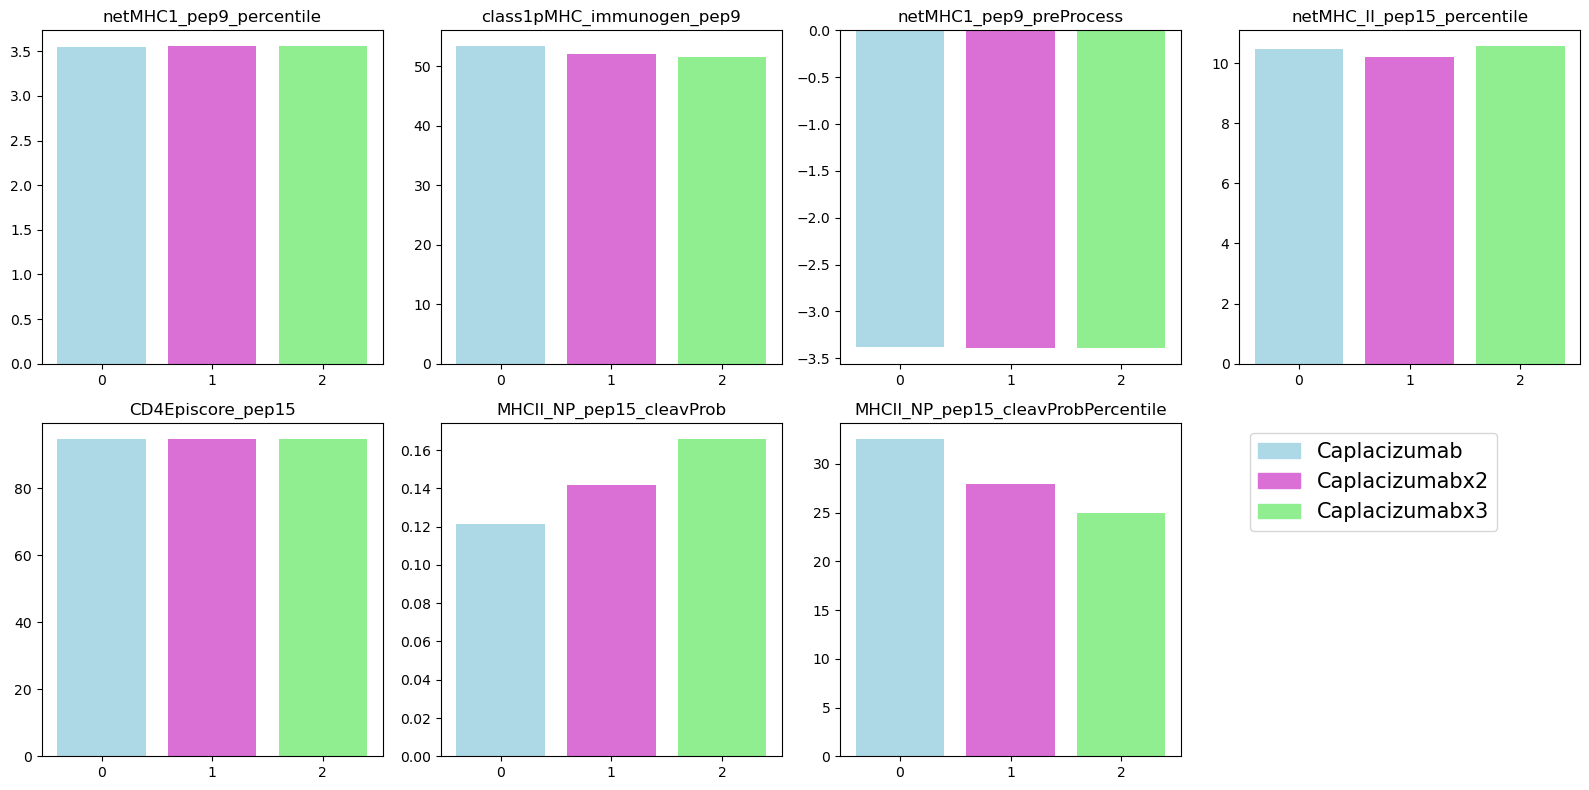

In [14]:


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ['lightblue', 'orchid', 'lightgreen']  # one per row

for i, col in enumerate(all_predictors.columns[1:]): # skip the first column with the sequence names
    ax = axes[i]
    
    values = all_predictors[col].values # 3 values (rows)
    x = np.arange(len(values)) # [0, 1, 2]
    
    ax.bar(x, values, color=colors)
    ax.set_title(col)
    ax.set_xticks(x)
    ax.set_xticklabels(all_predictors.index)      # row names (optional)
    
# Use last subplot for legend
legend_ax = axes[-1]
legend_ax.axis('off')  # remove axes

# create legend handles
handles = [
    mpatches.Patch(
        color=colors[i],
        label=all_predictors['sequence name'].iloc[i]
    )
    for i in range(len(all_predictors))
]

# add legend to the last subplot
legend_ax.legend(handles=handles, loc='upper left', fontsize=15)

plt.tight_layout()
plt.show()

Short tool score explanation:\
**netMHC percentile**, this score is the percentage of HLA-peptide interactions that have an immunogenetic percentile score. Immunogenetic score is scores below 1. The percentile score is a comparison of the peptide IC50 score to a set of random peptides from Uniprot/Swiss-prot.\
**netMHC immunogenicity score**, this score is the percentage of HLA-peptide interactions that have an immunogenetic immunogenicity score. Immunogenetic immunogenicity score is scores above 0.
**netMHC II percentile**, same as for netMHC. But immunogenetic scores are scores below 10.\
**netMHC immunogenicity score**, this score is the mean of the HLA-peptide interaction for each antibody. Low value means more immunogenetic.\
**netMHC II cleavage probability score**, this is the mean of the HLA-peptide interaction for each antibody. Higher number means better chance of the peptide being a ligand.\
**netMHC II cleavage probability percentile score**, this is the mean of the HLA-peptide interaction for each antibody. Lower number means better chance of the peptide being a ligand.
